<a href="https://colab.research.google.com/github/nasuhaerza/AVD-Forum-9/blob/main/411231142_Nasuha_Erza_As_Shifa_Forum_Pertemuan_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SISTEM BASIS DATA PERUSAHAAN

=== DAFTAR PEMINJAMAN ===
   id nama_anggota       judul_buku  tgl_pinjam tgl_kembali
0   1       Nasuha   Laskar Pelangi  2026-05-01  2026-05-07
1   2         Erza  Negeri 5 Menara  2026-05-03  2026-05-10
2   3       Nasuha             Bumi  2026-05-05        None
3   4        Shifa    Atomic Habits  2026-05-08  2026-05-15

=== JUMLAH BUKU YANG DIPINJAM SETIAP ANGGOTA ===
     nama  jumlah_buku
0    Erza            1
1  Nasuha            2
2   Shifa            1

=== DATAFRAME HASIL QUERY SQL ===
   id nama_anggota       judul_buku  tgl_pinjam tgl_kembali
0   1       Nasuha   Laskar Pelangi  2026-05-01  2026-05-07
1   2         Erza  Negeri 5 Menara  2026-05-03  2026-05-10
2   3       Nasuha             Bumi  2026-05-05        None
3   4        Shifa    Atomic Habits  2026-05-08  2026-05-15

=== DATA DURASI PEMINJAMAN ===
   id nama_anggota       judul_buku tgl_pinjam tgl_kembali  durasi_hari
0   1       Nasuha   Laskar Pelangi 2026-05-01  2026-05-07          6.0
1   2         Erza  N

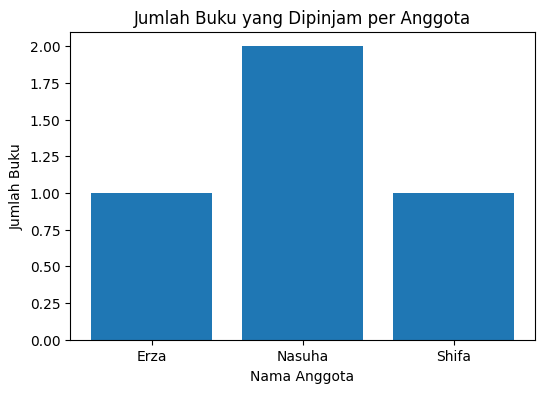

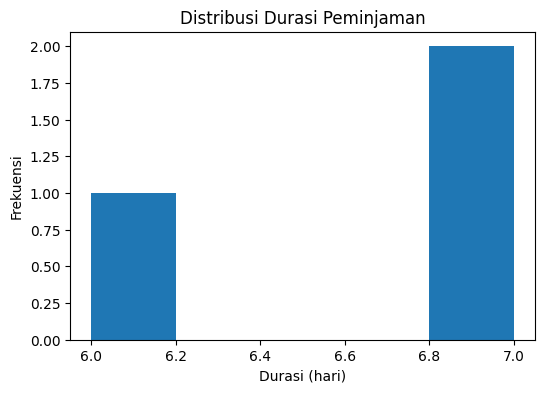

In [ ]:
# Import library
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Koneksi database SQLite
conn = sqlite3.connect('perpustakaan.db')
cursor = conn.cursor()

# 1. MEMBUAT TABEL

# Tabel buku
cursor.execute("""
CREATE TABLE IF NOT EXISTS buku (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    judul TEXT NOT NULL,
    penulis TEXT NOT NULL,
    tahun INTEGER
)
""")

# Tabel anggota
cursor.execute("""
CREATE TABLE IF NOT EXISTS anggota (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    nama TEXT NOT NULL,
    email TEXT
)
""")

# Tabel peminjaman
cursor.execute("""
CREATE TABLE IF NOT EXISTS peminjaman (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    id_anggota INTEGER,
    id_buku INTEGER,
    tgl_pinjam TEXT,
    tgl_kembali TEXT,
    FOREIGN KEY (id_anggota) REFERENCES anggota(id),
    FOREIGN KEY (id_buku) REFERENCES buku(id)
)
""")

conn.commit()

# a. MENAMBAHKAN DATA BUKU DAN ANGGOTA

# Data buku
data_buku = [
    ('Laskar Pelangi', 'Andrea Hirata', 2005),
    ('Bumi', 'Tere Liye', 2014),
    ('Negeri 5 Menara', 'Ahmad Fuadi', 2009),
    ('Atomic Habits', 'James Clear', 2018),
    ('Rich Dad Poor Dad', 'Robert Kiyosaki', 1997)
]

cursor.executemany("""
INSERT INTO buku (judul, penulis, tahun)
VALUES (?, ?, ?)
""", data_buku)

# Data anggota
data_anggota = [
    ('Nasuha', 'Nasuha@gmail.com'),
    ('Erza', 'Erza@gmail.com'),
    ('Shifa', 'Shifa@gmail.com')
]

cursor.executemany("""
INSERT INTO anggota (nama, email)
VALUES (?, ?)
""", data_anggota)

conn.commit()

# b. MENAMBAHKAN DATA PEMINJAMAN

data_peminjaman = [
    (1, 1, '2026-05-01', '2026-05-07'),
    (2, 3, '2026-05-03', '2026-05-10'),
    (1, 2, '2026-05-05', None),  # Belum dikembalikan
    (3, 4, '2026-05-08', '2026-05-15')
]

cursor.executemany("""
INSERT INTO peminjaman (id_anggota, id_buku, tgl_pinjam, tgl_kembali)
VALUES (?, ?, ?, ?)
""", data_peminjaman)

conn.commit()

# 1c. MENAMPILKAN DAFTAR PEMINJAMAN (JOIN)

print("=== DAFTAR PEMINJAMAN ===")

query_join = """
SELECT
    peminjaman.id,
    anggota.nama AS nama_anggota,
    buku.judul AS judul_buku,
    peminjaman.tgl_pinjam,
    peminjaman.tgl_kembali
FROM peminjaman
JOIN anggota
    ON peminjaman.id_anggota = anggota.id
JOIN buku
    ON peminjaman.id_buku = buku.id
"""

df_peminjaman = pd.read_sql_query(query_join, conn)
print(df_peminjaman)

# 1d. JUMLAH TOTAL BUKU YANG DIPINJAM

print("\n=== JUMLAH BUKU YANG DIPINJAM SETIAP ANGGOTA ===")

query_group = """
SELECT
    anggota.nama,
    COUNT(peminjaman.id_buku) AS jumlah_buku
FROM peminjaman
JOIN anggota
    ON peminjaman.id_anggota = anggota.id
GROUP BY anggota.nama
"""

df_jumlah = pd.read_sql_query(query_group, conn)
print(df_jumlah)

# 2a. MEMBUAT DATAFRAME DARI QUERY SQL

print("\n=== DATAFRAME HASIL QUERY SQL ===")
print(df_peminjaman)

# 2b. EKSPLORASI DATA
# Hitung durasi peminjaman

# Mengubah kolom tanggal menjadi format datetime
df_peminjaman['tgl_pinjam'] = pd.to_datetime(df_peminjaman['tgl_pinjam'])
df_peminjaman['tgl_kembali'] = pd.to_datetime(df_peminjaman['tgl_kembali'])

# Menghitung durasi peminjaman
df_peminjaman['durasi_hari'] = (
    df_peminjaman['tgl_kembali'] - df_peminjaman['tgl_pinjam']
).dt.days

print("\n=== DATA DURASI PEMINJAMAN ===")
print(df_peminjaman)

# Statistik sederhana
print("\n=== STATISTIK DURASI PEMINJAMAN ===")
print(df_peminjaman['durasi_hari'].describe())

# 2c. VISUALISASI DATA

# Diagram batang jumlah buku per anggota
plt.figure(figsize=(6,4))
plt.bar(df_jumlah['nama'], df_jumlah['jumlah_buku'])
plt.title('Jumlah Buku yang Dipinjam per Anggota')
plt.xlabel('Nama Anggota')
plt.ylabel('Jumlah Buku')
plt.show()

# Histogram durasi peminjaman
plt.figure(figsize=(6,4))

# Menghapus nilai NaN agar histogram tidak error
durasi_valid = df_peminjaman['durasi_hari'].dropna()

plt.hist(durasi_valid, bins=5)
plt.title('Distribusi Durasi Peminjaman')
plt.xlabel('Durasi (hari)')
plt.ylabel('Frekuensi')
plt.show()

# MENUTUP KONEKSI DATABASE

conn.close()